<a href="https://colab.research.google.com/github/mipaillafil/Proyecto_Aeropuertos_Cortes_Marchesse_Paillafil/blob/main/Evaluaci%C3%B3n_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Carga y Visión General del Dataset

In [4]:
#Se carga el dataset que se limpio la evaluación anterior
url = "https://raw.githubusercontent.com/mipaillafil/Proyecto_Aeropuertos_Cortes_Marchesse_Paillafil/main/data/operaciones_aeropuertos_clean.csv"
df = pd.read_csv(url)
display(df.head())

,cnt_operaciones,total_operaciones,mes_id_200001.0,mes_id_200002.0,mes_id_200003.0,mes_id_200004.0,mes_id_200005.0,mes_id_200006.0,mes_id_200007.0,mes_id_200008.0,...,aeropuerto_oaci_SCVD,aeropuerto_oaci_SCVH,aeropuerto_oaci_SCVI,aeropuerto_oaci_SCVL,aeropuerto_oaci_SCVM,aeropuerto_oaci_SCVV,aeropuerto_oaci_nan,internacional_domestico_D,internacional_domestico_I,internacional_domestico_nan
0,-0.555716,-0.555716,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.029270,0.029270,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.442135,-0.442135,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.234614,-0.234614,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.490812,-0.490812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 3. Exploración general

In [5]:
# Mostramos la informacion general del dataset
print("Informacion general:")
df.info()

# Mostramos los nombres de columnas
print("Columnas del dataset:")
print(df.columns)

Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14398 entries, 0 to 14397
Columns: 387 entries, cnt_operaciones to internacional_domestico_nan
dtypes: float64(387)
memory usage: 42.5 MB
Columnas del dataset:
Index(['cnt_operaciones', 'total_operaciones', 'mes_id_200001.0',
       'mes_id_200002.0', 'mes_id_200003.0', 'mes_id_200004.0',
       'mes_id_200005.0', 'mes_id_200006.0', 'mes_id_200007.0',
       'mes_id_200008.0',
       ...
       'aeropuerto_oaci_SCVD', 'aeropuerto_oaci_SCVH', 'aeropuerto_oaci_SCVI',
       'aeropuerto_oaci_SCVL', 'aeropuerto_oaci_SCVM', 'aeropuerto_oaci_SCVV',
       'aeropuerto_oaci_nan', 'internacional_domestico_D',
       'internacional_domestico_I', 'internacional_domestico_nan'],
      dtype='object', length=387)


## 4. Definición de variables

In [6]:
# Variable objetivo
# Se desea predecir si una operacion aerea corresponde a un vuelo domestico o no
target = "internacional_domestico_D"

# Variables predictoras (X)
# Se eliminan la variable objetivo y la otra variable dummy relacionada porque ambas contienen la misma informacion categorica
X = df.drop([
    "internacional_domestico_D",
    "internacional_domestico_I"
], axis=1)

# Variable objetivo (y)

y = df[target]

# Mostramos dimensiones del dataset
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Mostramos ejemplos de las variables
print("Primeras filas de X:")
display(X.head())

print("Primeras filas de y:")
display(y.head())

Dimensiones de X: (14398, 385)
Dimensiones de y: (14398,)
Primeras filas de X:


,cnt_operaciones,total_operaciones,mes_id_200001.0,mes_id_200002.0,mes_id_200003.0,mes_id_200004.0,mes_id_200005.0,mes_id_200006.0,mes_id_200007.0,mes_id_200008.0,...,aeropuerto_oaci_SCTN,aeropuerto_oaci_SCTS,aeropuerto_oaci_SCVD,aeropuerto_oaci_SCVH,aeropuerto_oaci_SCVI,aeropuerto_oaci_SCVL,aeropuerto_oaci_SCVM,aeropuerto_oaci_SCVV,aeropuerto_oaci_nan,internacional_domestico_nan
0,-0.555716,-0.555716,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.029270,0.029270,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.442135,-0.442135,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.234614,-0.234614,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.490812,-0.490812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Primeras filas de y:


,internacional_domestico_D
0,1.0
1,1.0
2,0.0
3,1.0
4,1.0


## 5. División de datos

In [7]:
# Se dividen los datos en el 80% entrenamiento y 20% prueba
# random_state nos permite reproducir resultados
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostramos dimensiones de entrenamiento y prueba
print("Datos de entrenamiento:")
print(X_train.shape)

print("Datos de prueba:")
print(X_test.shape)

# Mostramos dimensiones de las variables objetivo
print("y_train:")
print(y_train.shape)

print("y_test:")
print(y_test.shape)

Datos de entrenamiento:
(11518, 385)
Datos de prueba:
(2880, 385)
y_train:
(11518,)
y_test:
(2880,)


## 6. Escalado de Variables

In [8]:
# Crear escalador
scaler = StandardScaler()

# Ajustar solo con datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Transformar datos de prueba usando el mismo escalador
X_test_scaled = scaler.transform(X_test)

# Verificar dimensiones
print("Datos escalados correctamente.")

print("\nX_train escalado:")
print(X_train_scaled.shape)

print("\nX_test escalado:")
print(X_test_scaled.shape)

Datos escalados correctamente.

X_train escalado:
(11518, 385)

X_test escalado:
(2880, 385)


## 7. Modelo 1: Logistic Regression

MODELO: LOGISTIC REGRESSION
Accuracy Logistic Regression: 0.9260
Precision Logistic Regression: 0.9248
Recall Logistic Regression: 0.9260
F1-Score Logistic Regression: 0.9244
Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84       689
         1.0       0.93      0.97      0.95      2191

    accuracy                           0.93      2880
   macro avg       0.91      0.88      0.89      2880
weighted avg       0.92      0.93      0.92      2880



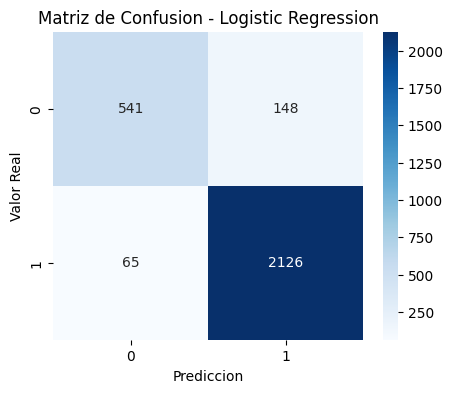

In [9]:
print("MODELO: LOGISTIC REGRESSION")

# Creamos modelo logistic regression
# max_iter aumenta iteraciones para asegurar convergencia
lr = LogisticRegression(max_iter=1000)

# Entrenamos modelo
lr.fit(X_train, y_train)

# Realizamos predicciones
pred_lr = lr.predict(X_test)

# Calculamos accuracy del modelo
acc_lr = accuracy_score(y_test, pred_lr)

# Obtener métricas de clasificación
report_lr = classification_report(y_test, pred_lr, output_dict=True)
precision_lr = report_lr['weighted avg']['precision']
recall_lr = report_lr['weighted avg']['recall']
f1_lr = report_lr['weighted avg']['f1-score']

print(f"Accuracy Logistic Regression: {acc_lr:.4f}")
print(f"Precision Logistic Regression: {precision_lr:.4f}")
print(f"Recall Logistic Regression: {recall_lr:.4f}")
print(f"F1-Score Logistic Regression: {f1_lr:.4f}")

# Mostramos las metricas completas
print("Classification Report:")
print(classification_report(y_test, pred_lr))

# Creamos la matriz de confusion
cm_lr = confusion_matrix(y_test, pred_lr)

# Visualizamos la matriz de confusion
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusion - Logistic Regression")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")

plt.show()

## 8. Modelo 2: Decision Tree

MODELO: DECISION TREE

Accuracy Decision Tree: 0.9396
Precision Decision Tree: 0.9396
Recall Decision Tree: 0.9396
F1-Score Decision Tree: 0.9396

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.87       689
         1.0       0.96      0.96      0.96      2191

    accuracy                           0.94      2880
   macro avg       0.92      0.92      0.92      2880
weighted avg       0.94      0.94      0.94      2880



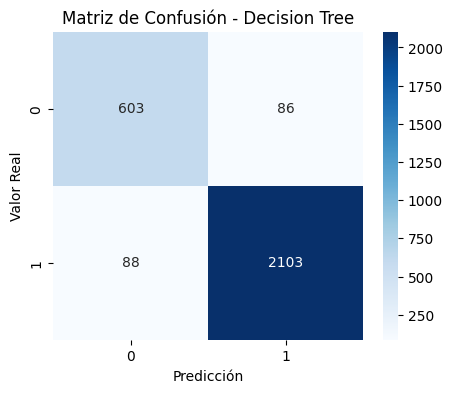

In [10]:
print("MODELO: DECISION TREE")

# Crear modelo de árbol de decisión
dt = DecisionTreeClassifier(random_state=42)

# Entrenar modelo
dt.fit(X_train, y_train)

# Realizar predicciones
pred_dt = dt.predict(X_test)

# Calcular accuracy
acc_dt = accuracy_score(y_test, pred_dt)

# Obtener métricas de clasificación
report_dt = classification_report(y_test, pred_dt, output_dict=True)
precision_dt = report_dt['weighted avg']['precision']
recall_dt = report_dt['weighted avg']['recall']
f1_dt = report_dt['weighted avg']['f1-score']

print(f"\nAccuracy Decision Tree: {acc_dt:.4f}")
print(f"Precision Decision Tree: {precision_dt:.4f}")
print(f"Recall Decision Tree: {recall_dt:.4f}")
print(f"F1-Score Decision Tree: {f1_dt:.4f}")

# Mostrar métricas
print("\nClassification Report:")
print(classification_report(y_test, pred_dt))

# Crear matriz de confusión
cm_dt = confusion_matrix(y_test, pred_dt)

# Visualización
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Decision Tree")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## 9. Modelo 3: Random Forest

MODELO: RANDOM FOREST

Accuracy Random Forest: 0.9479
Precision Random Forest: 0.9478
Recall Random Forest: 0.9479
F1-Score Random Forest: 0.9479

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89       689
         1.0       0.96      0.97      0.97      2191

    accuracy                           0.95      2880
   macro avg       0.93      0.93      0.93      2880
weighted avg       0.95      0.95      0.95      2880



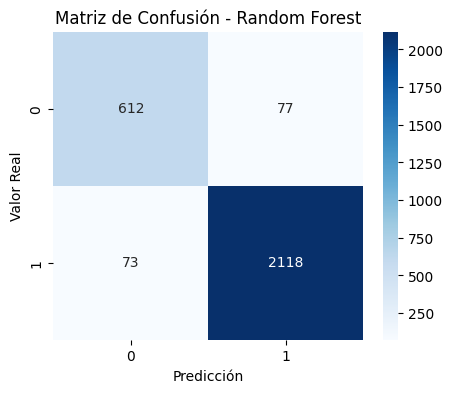

In [11]:
print("MODELO: RANDOM FOREST")

# Crear modelo Random Forest
rf = RandomForestClassifier(random_state=42)

# Entrenar modelo
rf.fit(X_train, y_train)

# Realizar predicciones
pred_rf = rf.predict(X_test)

# Calcular accuracy
acc_rf = accuracy_score(y_test, pred_rf)

# Obtener métricas de clasificación
report_rf = classification_report(y_test, pred_rf, output_dict=True)
precision_rf = report_rf['weighted avg']['precision']
recall_rf = report_rf['weighted avg']['recall']
f1_rf = report_rf['weighted avg']['f1-score']

print(f"\nAccuracy Random Forest: {acc_rf:.4f}")
print(f"Precision Random Forest: {precision_rf:.4f}")
print(f"Recall Random Forest: {recall_rf:.4f}")
print(f"F1-Score Random Forest: {f1_rf:.4f}")

# Mostrar métricas completas
print("\nClassification Report:")
print(classification_report(y_test, pred_rf))

# Crear matriz de confusión
cm_rf = confusion_matrix(y_test, pred_rf)

# Visualizar matriz de confusión
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Random Forest")

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

## 10. Modelo 4: Support Vector Machine (SVM)

SUPPORT VECTOR MACHINE (SVM)

Accuracy: 0.9083
Precision SVM: 0.9116
Recall SVM: 0.9083
F1-Score SVM: 0.9021

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.65      0.77       689
         1.0       0.90      0.99      0.94      2191

    accuracy                           0.91      2880
   macro avg       0.92      0.82      0.86      2880
weighted avg       0.91      0.91      0.90      2880



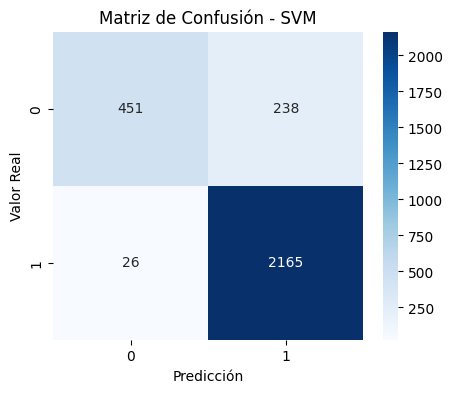

In [12]:
print("SUPPORT VECTOR MACHINE (SVM)")
# Crear modelo
svm = SVC(kernel='rbf', random_state=42)

# Entrenar con datos escalados
svm.fit(X_train_scaled, y_train)

# Predicciones
pred_svm = svm.predict(X_test_scaled)

# Accuracy
acc_svm = accuracy_score(y_test, pred_svm)

# Obtener métricas de clasificación
report_svm = classification_report(y_test, pred_svm, output_dict=True)
precision_svm = report_svm['weighted avg']['precision']
recall_svm = report_svm['weighted avg']['recall']
f1_svm = report_svm['weighted avg']['f1-score']

print(f"\nAccuracy: {acc_svm:.4f}")
print(f"Precision SVM: {precision_svm:.4f}")
print(f"Recall SVM: {recall_svm:.4f}")
print(f"F1-Score SVM: {f1_svm:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, pred_svm))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## 11. Comparación de Modelos

In [13]:
# Crear un DataFrame para comparar los resultados de todos los modelos
# Incluye las métricas de Accuracy, Precision, Recall y F1-Score para cada modelo
resultados = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine'
    ],
    'Accuracy': [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_svm
    ],
    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm
    ],
    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_svm
    ],
    'F1-Score': [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm
    ]
})

# Imprimir un encabezado y mostrar la tabla de comparación de modelos
print("\nComparación completa de modelos:\n")
display(resultados)


Comparación completa de modelos:



,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.926042,0.924826,0.926042,0.924359
1,Decision Tree,0.939583,0.939644,0.939583,0.939613
2,Random Forest,0.947917,0.947817,0.947917,0.947865
3,Support Vector Machine,0.908333,0.911612,0.908333,0.902115


##12. Cross Validation

##13. Overfitting

##14. Mejor Modelo

#15. Conclusión Técnica